# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

[Te proporcionamos algunos comentarios para orientarte mientras completas este proyecto. Pero debes asegurarte de eliminar todos los comentarios entre corchetes antes de entregar tu proyecto.]

[Antes de sumergirte en el análisis de datos, explica por tu propia cuenta el propósito del proyecto y las acciones que planeas realizar.]

[Ten en cuenta que estudiar, modificar y analizar datos es un proceso iterativo. Es normal volver a los pasos anteriores y corregirlos/ampliarlos para permitir nuevos pasos.]

## Inicialización

In [1]:

# Cargar todas las librerías
import pandas as pd
import math
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats as st


## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrames

#Ruta de la plataforma
# calls = pd.read_csv('/datasets/megaline_calls.csv')
# internet = pd.read_csv('/datasets/megaline_internet.csv')
# messages = pd.read_csv('/datasets/megaline_messages.csv')
# plans = pd.read_csv('/datasets/megaline_plans.csv')
# users = pd.read_csv('/datasets/megaline_users.csv')

In [3]:
# Carga los archivos de datos en diferentes DataFrames
#IMPORTANTE: este bloque no es estrictamente necesario, pero es util al correr en local

try:
    #Ruta de la plataforma
    calls    = pd.read_csv('/datasets/megaline_calls.csv')
    internet = pd.read_csv('/datasets/megaline_internet.csv')
    messages = pd.read_csv('/datasets/megaline_messages.csv')
    plans    = pd.read_csv('/datasets/megaline_plans.csv')
    users    = pd.read_csv('/datasets/megaline_users.csv')
except:
    # ruta local (archivo en repositorio)
    calls    = pd.read_csv('DATA/megaline_calls.csv')
    internet = pd.read_csv('DATA/megaline_internet.csv')
    messages = pd.read_csv('DATA/megaline_messages.csv')
    plans    = pd.read_csv('DATA/megaline_plans.csv')
    users    = pd.read_csv('DATA/megaline_users.csv')
    
    # ruta para acceder a datos en linea
    # calls    = pd.read_csv('https://code.s3.yandex.net/datasets/megaline_calls.csv')
    # internet = pd.read_csv('https://code.s3.yandex.net/datasets/megaline_internet.csv')
    # messages = pd.read_csv('https://code.s3.yandex.net/datasets/megaline_messages.csv')
    # plans    = pd.read_csv('https://code.s3.yandex.net/datasets/megaline_plans.csv')
    # users    = pd.read_csv('https://code.s3.yandex.net/datasets/megaline_users.csv')

## Preparar los datos

[Los datos para este proyecto se dividen en varias tablas. Explora cada una para tener una comprensión inicial de los datos. Si es necesario, haz las correcciones requeridas en cada tabla.]

### Tarifas

In [4]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


In [5]:
# Imprime una muestra de los datos para las tarifas
plans

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

#### Corregir datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [6]:
#cambiar unidad de columna
plans['mb_per_month_included'] = plans['mb_per_month_included']/1024
plans = plans.rename(columns={'mb_per_month_included':'gb_per_month'})
plans.head()

,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15.0,500,20,10,0.03,0.03,surf
1,1000,30.0,3000,70,7,0.01,0.01,ultimate


#### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

### Usuarios/as

In [7]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [8]:
# Imprime una muestra de datos para usuarios
users.head(3)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

#### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [9]:
users['reg_date']    = pd.to_datetime(users['reg_date'], format='%Y-%m-%d')
users['churn_date']  = pd.to_datetime(users['churn_date'], format='%Y-%m-%d')
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB


#### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

### Llamadas

In [10]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [11]:
# Imprime una muestra de datos para las llamadas
calls.head(3)

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

#### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [12]:
calls['call_date'] = pd.to_datetime(calls['call_date'], format='%Y-%m-%d')

In [13]:
calls.describe()

,user_id,call_date,duration
count,137735.000000,137735,137735.000000
mean,1247.658046,2018-09-25 19:57:56.319018496,6.745927
min,1000.000000,2018-01-15 00:00:00,0.000000
25%,1128.000000,2018-08-08 00:00:00,1.290000
50%,1247.000000,2018-10-12 00:00:00,5.980000
75%,1365.000000,2018-11-26 00:00:00,10.690000
max,1499.000000,2018-12-31 00:00:00,37.600000
std,139.416268,NaN,5.839241


In [14]:
#eliminar filas con llamadas de duración 0
calls = calls[calls['duration']!=0]

In [15]:
# redondear minutos hacia arriba
# calls['duration'] = calls['duration'].apply(math.ceil)
calls['duration'] = np.ceil(calls['duration'])
calls.head(3)

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,9.0
1,1000_145,1000,2018-12-27,14.0
2,1000_247,1000,2018-12-27,15.0


In [16]:
# comprobar cambios
calls.describe()

,user_id,call_date,duration
count,110901.000000,110901,110901.000000
mean,1247.511871,2018-09-25 18:38:58.193524224,8.875907
min,1000.000000,2018-01-15 00:00:00,1.000000
25%,1127.000000,2018-08-08 00:00:00,5.000000
50%,1247.000000,2018-10-12 00:00:00,8.000000
75%,1365.000000,2018-11-26 00:00:00,12.000000
max,1499.000000,2018-12-31 00:00:00,38.000000
std,139.475249,NaN,5.355181


#### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [17]:
#agregar columna mes

# Solución básica: extaer mes (no lo más optimo, en caso de tener fechas de distintos años)
calls['month'] = calls['call_date'].dt.month 

# Solución optima: extraer año y mes
calls['month_year'] = calls['call_date'].dt.to_period('M').astype(str)
calls.head(3)

,id,user_id,call_date,duration,month,month_year
0,1000_93,1000,2018-12-27,9.0,12,2018-12
1,1000_145,1000,2018-12-27,14.0,12,2018-12
2,1000_247,1000,2018-12-27,15.0,12,2018-12


### Mensajes

In [18]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [19]:
# Imprime una muestra de datos para los mensajes
messages.head()

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

#### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [20]:
messages['message_date'] = pd.to_datetime(messages['message_date'], format='%Y-%m-%d')

#### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [21]:
#agregar columna mes

# Solución básica: extaer mes (no lo más optimo, en caso de tener fechas de distintos años)
messages['month'] = messages['message_date'].dt.month 

# Solución optima: extraer año y mes
messages['month_year'] = messages['message_date'].dt.to_period('M').astype(str)
messages.head(3)

,id,user_id,message_date,month,month_year
0,1000_125,1000,2018-12-27,12,2018-12
1,1000_160,1000,2018-12-31,12,2018-12
2,1000_223,1000,2018-12-31,12,2018-12


### Internet

In [22]:
# Imprime la información general/resumida sobre el DataFrame de internet
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [23]:
internet.head()

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

#### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [24]:
internet['session_date']  = pd.to_datetime(internet['session_date'], format='%Y-%m-%d')

#### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [25]:
#agregar columna mes

# Solución básica: extaer mes (no lo más optimo, en caso de tener fechas de distintos años)
internet['month'] = internet['session_date'].dt.month 

# Solución optima: extraer año y mes
internet['month_year'] = internet['session_date'].dt.to_period('M').astype(str)
internet.head(3)

,id,user_id,session_date,mb_used,month,month_year
0,1000_13,1000,2018-12-29,89.86,12,2018-12
1,1000_204,1000,2018-12-31,0.00,12,2018-12
2,1000_379,1000,2018-12-28,660.40,12,2018-12


## Estudiar las condiciones de las tarifas

[Es sumamente importante entender cómo funcionan las tarifas, cómo se les cobra a los usuarios en función de su plan de suscripción. Así que te sugerimos imprimir la información de la tarifa para ver una vez más sus condiciones.]

In [26]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
plans

,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15.0,500,20,10,0.03,0.03,surf
1,1000,30.0,3000,70,7,0.01,0.01,ultimate


## Agregar datos por usuario

[Ahora que los datos están limpios, agrega los datos por usuario y por periodo para que solo haya un registro por usuario y por periodo. Esto facilitará mucho el análisis posterior.]

In [27]:
# vista previa
calls.head(3)

,id,user_id,call_date,duration,month,month_year
0,1000_93,1000,2018-12-27,9.0,12,2018-12
1,1000_145,1000,2018-12-27,14.0,12,2018-12
2,1000_247,1000,2018-12-27,15.0,12,2018-12


In [28]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.

#SÓLUCIÓN BASICA con groupby() (los alumnos no han visto groupby con .agg())

# Total de minutos usados por usuario y mes
total_minutes = calls.groupby(['user_id', 'month_year'])['duration'].sum().reset_index()
total_minutes.rename(columns={'duration': 'minutes_used'}, inplace=True)

# Número de llamadas por usuario y mes
call_counts = calls.groupby(['user_id', 'month_year'])['duration'].count().reset_index()
call_counts.rename(columns={'duration': 'calls_made'}, inplace=True)

# Unir ambos resultados
month_calls = pd.merge(total_minutes, call_counts, on=['user_id', 'month_year'])

month_calls.head(3)

,user_id,month_year,minutes_used,calls_made
0,1000,2018-12,124.0,16
1,1001,2018-08,182.0,22
2,1001,2018-09,315.0,38


In [29]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.

# SOLUCIÓN avanzada: groupby() + agg (los alumnos no han visto groupby con .agg())
month_calls = calls.groupby(['user_id', 'month_year']).agg(minutes_used=('duration', 'sum'),
                                                           calls_made=('duration', 'count')
                                                           ).reset_index()

# SOLUCIÓN con pivot_table
month_calls = calls.pivot_table(index = ['user_id', 'month_year'], 
                                values = 'duration', aggfunc = ['sum','count'])
month_calls.columns = ['minutes_used', 'calls_made']
month_calls.reset_index(inplace=True)

month_calls.head(3)

,user_id,month_year,minutes_used,calls_made
0,1000,2018-12,124.0,16
1,1001,2018-08,182.0,22
2,1001,2018-09,315.0,38


In [30]:
messages.head(3)

,id,user_id,message_date,month,month_year
0,1000_125,1000,2018-12-27,12,2018-12
1,1000_160,1000,2018-12-31,12,2018-12
2,1000_223,1000,2018-12-31,12,2018-12


In [31]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.

#SÓLUCIÓN BASICA con groupby()
month_mess = messages.groupby(['user_id','month_year'])['id'].count().reset_index()
month_mess = month_mess.rename(columns={'id':'num_mess'})

# SOLUCIÓN con pivot_table
month_mess = messages.pivot_table(index = ['user_id', 'month_year'], values = 'id', aggfunc = 'count').reset_index()
month_mess = month_mess.rename(columns={'id':'num_mess'})

month_mess.head(3)

,user_id,month_year,num_mess
0,1000,2018-12,11
1,1001,2018-08,30
2,1001,2018-09,44


In [32]:
internet.head(3)

,id,user_id,session_date,mb_used,month,month_year
0,1000_13,1000,2018-12-29,89.86,12,2018-12
1,1000_204,1000,2018-12-31,0.00,12,2018-12
2,1000_379,1000,2018-12-28,660.40,12,2018-12


In [33]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.

#SÓLUCIÓN BASICA con groupby()
month_int = internet.groupby(['user_id','month_year'])['mb_used'].sum().reset_index()

# SOLUCIÓN con pivot_table
month_int = internet.pivot_table(index = ['user_id', 'month_year'], values = 'mb_used', aggfunc = 'sum').reset_index()
month_int.head(3)

,user_id,month_year,mb_used
0,1000,2018-12,1901.47
1,1001,2018-08,6919.15
2,1001,2018-09,13314.82


In [34]:
# Para el tráfico web, el total del mes se redondea hacia arriba
month_int['gb_used'] = (month_int['mb_used']/1024).apply(math.ceil)
month_int['gb_used'] = np.ceil(month_int['mb_used']/1024)
month_int.head(3)

,user_id,month_year,mb_used,gb_used
0,1000,2018-12,1901.47,2.0
1,1001,2018-08,6919.15,7.0
2,1001,2018-09,13314.82,14.0


[Junta los datos agregados en un DataFrame para que haya un registro que represente lo que consumió un usuario único en un mes determinado.]

In [35]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
#IMPORTANTE: OUTER es necesario para no perder información de clientes que no usan todos los servicios
df_monthly = month_calls.merge(month_mess, on=['user_id','month_year'],how='outer')
df_monthly = df_monthly.merge(month_int,on=['user_id','month_year'],how='outer')
df_monthly.info()
df_monthly.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2293 entries, 0 to 2292
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   user_id       2293 non-null   int64  
 1   month_year    2293 non-null   object 
 2   minutes_used  2256 non-null   float64
 3   calls_made    2256 non-null   float64
 4   num_mess      1806 non-null   float64
 5   mb_used       2277 non-null   float64
 6   gb_used       2277 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 125.5+ KB


,user_id,month_year,minutes_used,calls_made,num_mess,mb_used,gb_used
0,1000,2018-12,124.0,16.0,11.0,1901.47,2.0
1,1001,2018-08,182.0,22.0,30.0,6919.15,7.0
2,1001,2018-09,315.0,38.0,44.0,13314.82,14.0


Después de fusionar los datos, aparecieron valores ausentes debido a que algunos clientes no utilizan todos los servicios disponibles. 

Cuando un cliente no ha usado cierto servicio, esa columna queda con un valor NaN, el cual podemos rellenar con cero para indicar ausencia de uso.

In [36]:
# Rellenar valores ausentes
df_monthly.fillna(0, inplace=True)
df_monthly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2293 entries, 0 to 2292
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   user_id       2293 non-null   int64  
 1   month_year    2293 non-null   object 
 2   minutes_used  2293 non-null   float64
 3   calls_made    2293 non-null   float64
 4   num_mess      2293 non-null   float64
 5   mb_used       2293 non-null   float64
 6   gb_used       2293 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 125.5+ KB


In [37]:
# Añade la información de la tarifa
df_monthly = df_monthly.merge(users[["user_id", "city","plan" ]],on='user_id',how='left')
df_monthly = df_monthly.merge(plans,how='left', left_on="plan", right_on="plan_name")
df_monthly.drop(columns='plan_name', inplace=True)
df_monthly.head(3)

,user_id,month_year,minutes_used,calls_made,num_mess,mb_used,gb_used,city,plan,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,1000,2018-12,124.0,16.0,11.0,1901.47,2.0,"Atlanta-Sandy Springs-Roswell, GA MSA",ultimate,1000,30.0,3000,70,7,0.01,0.01
1,1001,2018-08,182.0,22.0,30.0,6919.15,7.0,"Seattle-Tacoma-Bellevue, WA MSA",surf,50,15.0,500,20,10,0.03,0.03
2,1001,2018-09,315.0,38.0,44.0,13314.82,14.0,"Seattle-Tacoma-Bellevue, WA MSA",surf,50,15.0,500,20,10,0.03,0.03


[Calcula los ingresos mensuales por usuario (resta el límite del paquete gratuito del número total de llamadas, mensajes de texto y datos; multiplica el resultado por el valor del plan de llamadas; añade la tarifa mensual en función del plan de llamadas). Nota: Dadas las condiciones del plan, ¡esto podría no ser tan trivial como un par de líneas! Así que no pasa nada si dedicas algo de tiempo a ello.]

In [38]:
# Calcula el ingreso mensual para cada usuario

#Función basica: unicamente funciona con los planes fijos
def monthly_income(row):
    if row['plan']=='ultimate':
        income = 70
        if row['num_mess'] > 1000: income += (row['num_mess']-1000) *0.01
        if row['gb_used']  > 30:   income += (row['gb_used']-30)    *7
        if row['minutes_used'] > 3000: income += (row['minutes_used']-3000) *0.01
        row['income']=income
    else:
        income = 20
        if row['num_mess'] > 50:  income += (row['num_mess']-50)  *0.03
        if row['gb_used']  > 15:  income += (row['gb_used']-15)   *10
        if row['minutes_used'] > 500: income += (row['minutes_used']-500) *0.03
        row['income']=income
        
    return row

# #Función completa: tomar los datos directo de la tabla
def monthly_income(row):
        income = row["usd_monthly_pay"]
                
        if row['num_mess'] > row["messages_included"]:     income += (row['num_mess'] -row["messages_included"]) * row["usd_per_message"]
        if row['gb_used']  > row["gb_per_month"]:         income += (row['gb_used']  -row["gb_per_month"])      * row["usd_per_gb"]
        if row['minutes_used'] > row["minutes_included"]: income += (row['minutes_used']-row["minutes_included"]) * row["usd_per_minute"]
        
        row['income']=income
        
        return row
    

In [39]:
# calcular ingreso mensual para cada usuario
df_monthly = df_monthly.apply(monthly_income,axis=1)
df_monthly.head()

,user_id,month_year,minutes_used,calls_made,num_mess,mb_used,gb_used,city,plan,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,income
0,1000,2018-12,124.0,16.0,11.0,1901.47,2.0,"Atlanta-Sandy Springs-Roswell, GA MSA",ultimate,1000,30.0,3000,70,7,0.01,0.01,70.00
1,1001,2018-08,182.0,22.0,30.0,6919.15,7.0,"Seattle-Tacoma-Bellevue, WA MSA",surf,50,15.0,500,20,10,0.03,0.03,20.00
2,1001,2018-09,315.0,38.0,44.0,13314.82,14.0,"Seattle-Tacoma-Bellevue, WA MSA",surf,50,15.0,500,20,10,0.03,0.03,20.00
3,1001,2018-10,393.0,47.0,53.0,22330.49,22.0,"Seattle-Tacoma-Bellevue, WA MSA",surf,50,15.0,500,20,10,0.03,0.03,90.09
4,1001,2018-11,426.0,49.0,36.0,18504.30,19.0,"Seattle-Tacoma-Bellevue, WA MSA",surf,50,15.0,500,20,10,0.03,0.03,60.00


## Estudia el comportamiento de usuario

[Calcula algunas estadísticas descriptivas para los datos agregados y fusionados que nos sean útiles y que muestren un panorama general captado por los datos. Dibuja gráficos útiles para facilitar la comprensión. Dado que la tarea principal es comparar las tarifas y decidir cuál es más rentable, las estadísticas y gráficas deben calcularse por tarifa.]

[En los comentarios hallarás pistas relevantes para las llamadas, pero no las hay para los mensajes e Internet. Sin embargo, el principio del estudio estadístico que se aplica para ellos es el mismo que para las llamadas.]

### Llamadas

In [40]:
df_monthly.groupby(['month_year', 'plan'])['minutes_used'].mean().unstack()

plan,surf,ultimate
month_year,,
2018-01,203.000000,193.500000
2018-02,297.000000,403.142857
2018-03,330.000000,304.250000
2018-04,351.540000,336.857143
2018-05,399.584416,406.241379
2018-06,431.298969,370.957447
2018-07,449.983471,427.067797
2018-08,410.111111,421.436620
2018-09,414.226804,437.511628


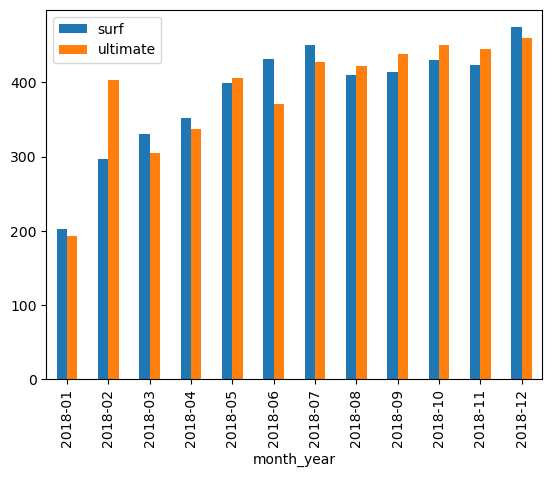

In [41]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
df_monthly.groupby(['month_year', 'plan'])['minutes_used'].mean().unstack().plot(kind="bar")
plt.legend(['surf', 'ultimate'])
plt.show()

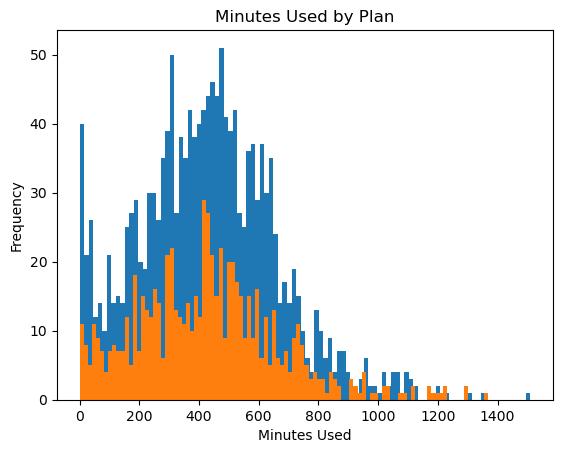

In [42]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.
df_monthly[df_monthly['plan'] == "surf"]["minutes_used"].plot(kind = 'hist', bins = 100)
df_monthly[df_monthly['plan'] == "ultimate"]["minutes_used"].plot(kind = 'hist', bins = 100)

plt.xlabel('Minutes Used')
plt.ylabel('Frequency')
plt.title('Minutes Used by Plan')
plt.show()

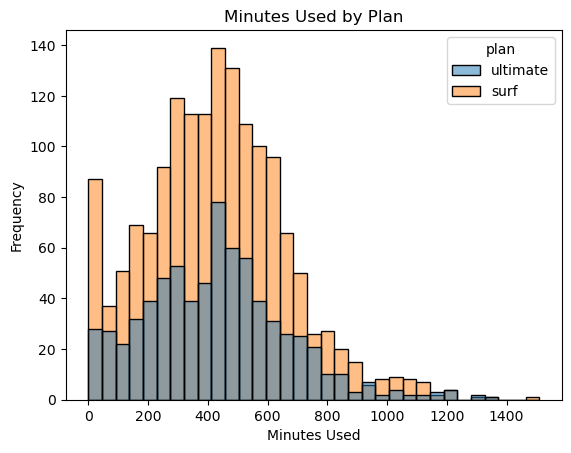

In [43]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.
#SOLUCION CON seaborn (no explicado en el curso)
sns.histplot(data=df_monthly, x="minutes_used", hue="plan")

plt.xlabel('Minutes Used')
plt.ylabel('Frequency')
plt.title('Minutes Used by Plan')
plt.show()

[Calcula la media y la variable de la duración de las llamadas para averiguar si los usuarios de los distintos planes se comportan de forma diferente al realizar sus llamadas.]

In [44]:
# Calcula la media y la varianza de la duración mensual de llamadas.

df_monthly.groupby('plan')['minutes_used'].describe()

,count,mean,std,min,25%,50%,75%,max
plan,,,,,,,,
surf,1573.0,428.749523,234.453150,0.0,272.0,425.0,576.00,1510.0
ultimate,720.0,430.450000,240.508762,0.0,260.0,424.0,565.25,1369.0


In [45]:
# varianza
print(np.var(df_monthly.query('plan == "ultimate"')['minutes_used']))
print(np.var(df_monthly.query('plan == "surf"')['minutes_used']))

57764.12527777776
54933.33459131743


In [46]:
# varianza mensual
df_monthly.groupby(['plan','month_year'])['minutes_used'].var(ddof=0)

plan      month_year
surf      2018-01        7921.000000
          2018-02       46423.555556
          2018-03       34252.434783
          2018-04       49849.408400
          2018-05       58978.190926
          2018-06       45122.601339
          2018-07       60500.925347
          2018-08       54009.185185
          2018-09       46355.773302
          2018-10       52058.078976
          2018-11       51424.664636
          2018-12       63429.426091
ultimate  2018-01       12429.250000
          2018-02       65905.265306
          2018-03       56819.520833
          2018-04       33227.551020
          2018-05       42329.286564
          2018-06       41599.232232
          2018-07       71333.486929
          2018-08       52889.936124
          2018-09       56406.854516
          2018-10       53750.005696
          2018-11       60116.110856
          2018-12       62089.851059
Name: minutes_used, dtype: float64

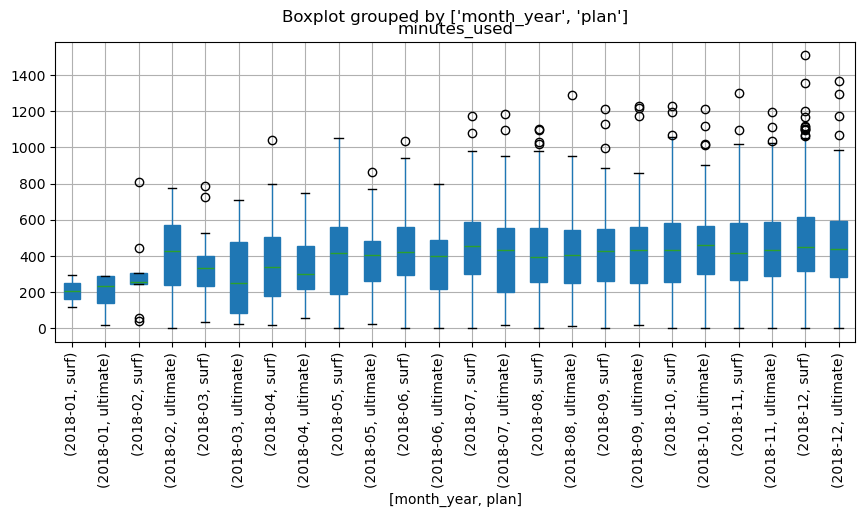

In [47]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas
# SOLUCIÓN 1
df_monthly.boxplot(column="minutes_used", by=["month_year","plan"], figsize=(10,4), patch_artist=True)
plt.xticks(rotation=90)
plt.show()

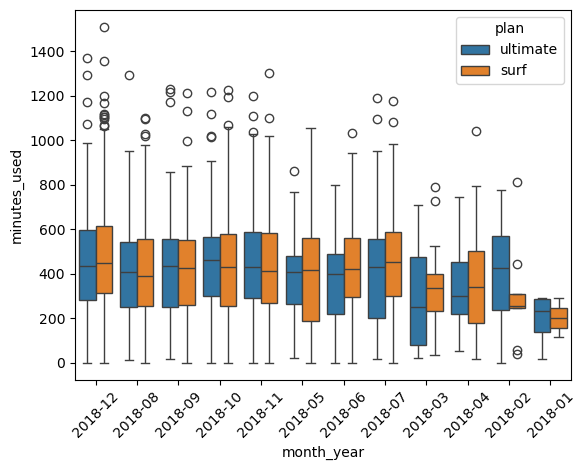

In [48]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas
# SOLUCIÓN 2: con seaborn (no visto en el curso)
sns.boxplot(data=df_monthly, x="month_year", y="minutes_used", hue="plan")
plt.xticks(rotation=45)
plt.show()

[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a las llamadas. ¿Su comportamiento varía en función del plan?]

### Mensajes

In [49]:
df_monthly.groupby(['month_year', 'plan'])['num_mess'].mean().unstack()

plan,surf,ultimate
month_year,,
2018-01,10.500000,15.500000
2018-02,12.000000,21.571429
2018-03,15.260870,20.250000
2018-04,17.400000,22.047619
2018-05,24.012987,32.103448
2018-06,25.298969,29.340426
2018-07,27.033058,32.830508
2018-08,28.777778,38.478873
2018-09,30.762887,37.895349


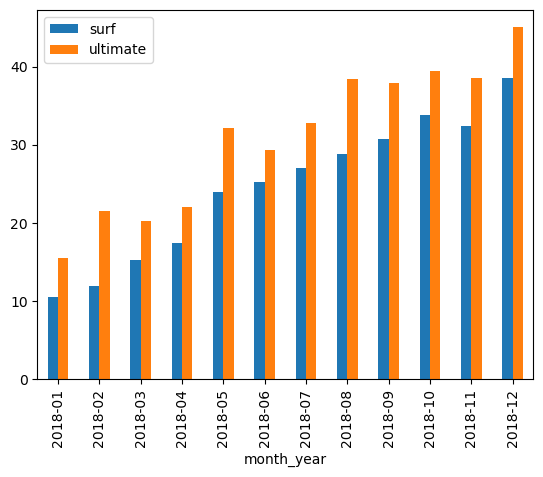

In [50]:
# Compara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
df_monthly.groupby(['month_year', 'plan'])['num_mess'].mean().unstack().plot(kind="bar")
plt.legend(['surf', 'ultimate'])
plt.show()

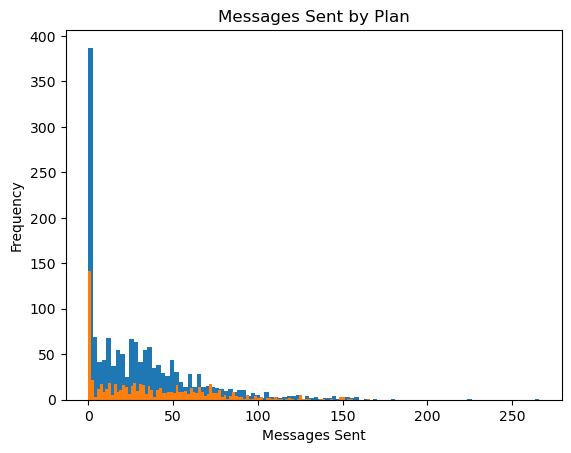

In [51]:
# Compara el número de mensajes mensuales que necesitan los usuarios de cada plan. Traza un histograma.
df_monthly[df_monthly['plan'] == "surf"]["num_mess"].plot(kind = 'hist', bins = 100)
df_monthly[df_monthly['plan'] == "ultimate"]["num_mess"].plot(kind = 'hist', bins = 100)

plt.xlabel('Messages Sent')
plt.ylabel('Frequency')
plt.title('Messages Sent by Plan')
plt.show()



In [52]:
# Calcula la media y la varianza de la cantidad mensual de mensajes enviados

# Media
df_monthly.groupby('plan')['num_mess'].describe()

,count,mean,std,min,25%,50%,75%,max
plan,,,,,,,,
surf,1573.0,31.159568,33.566717,0.0,3.0,24.0,47.0,266.0
ultimate,720.0,37.551389,34.767179,0.0,7.0,30.0,61.0,166.0


In [53]:
# varianza
print(np.var(df_monthly.query('plan == "ultimate"')['num_mess']))
print(np.var(df_monthly.query('plan == "surf"')['num_mess']))

1207.0779147376504
1126.0082317266638


In [54]:
# varianza mensual
df_monthly.groupby(['plan','month_year'])['num_mess'].var(ddof=0)

plan      month_year
surf      2018-01        110.250000
          2018-02        343.111111
          2018-03        331.497164
          2018-04        491.560000
          2018-05        836.194637
          2018-06        905.487937
          2018-07        916.279899
          2018-08       1023.160494
          2018-09        998.655117
          2018-10       1270.083997
          2018-11       1061.579568
          2018-12       1453.573207
ultimate  2018-01        235.250000
          2018-02        409.959184
          2018-03        599.854167
          2018-04        518.235828
          2018-05       1252.575505
          2018-06        839.373472
          2018-07        944.208561
          2018-08       1179.517159
          2018-09       1038.698350
          2018-10       1209.586419
          2018-11       1222.963110
          2018-12       1539.158897
Name: num_mess, dtype: float64

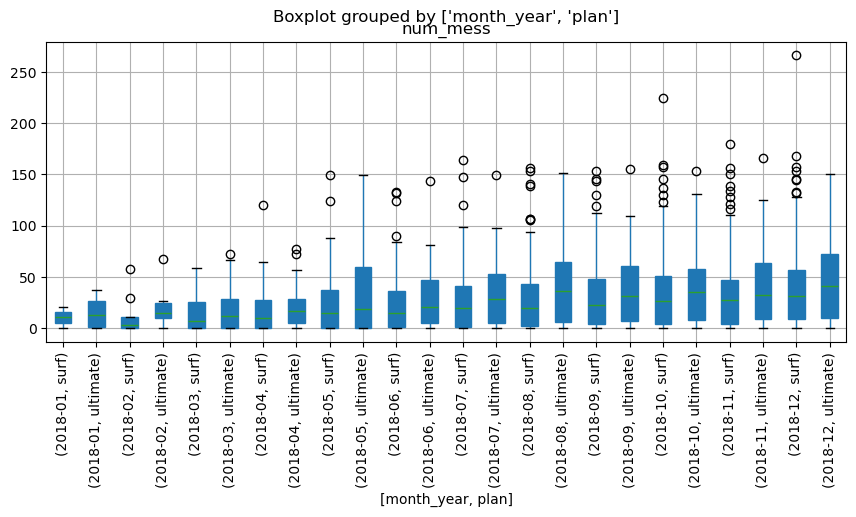

In [55]:
# diagrama de caja para visualizar la distribución de la cantidad mensual de mensajes enviados
# SOLUCIÓN 1
df_monthly.boxplot(column="num_mess", by=["month_year","plan"], figsize=(10,4), patch_artist=True)
plt.xticks(rotation=90)
plt.show()

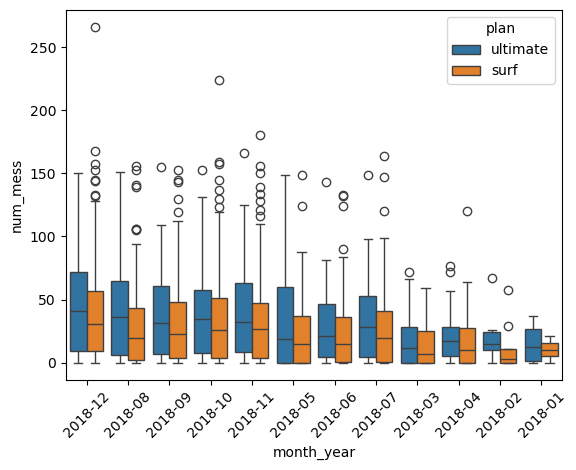

In [56]:
# Traza un diagrama de caja para visualizar la distribución de la cantidad mensual de mensajes enviados
# SOLUCIÓN 2: con seaborn (no visto en el curso)
sns.boxplot(data=df_monthly, x="month_year", y="num_mess", hue="plan")
plt.xticks(rotation=45)
plt.show()

[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a los mensajes. ¿Su comportamiento varía en función del plan?]

### Internet

In [57]:
df_monthly.groupby(['month_year', 'plan'])['gb_used'].mean().unstack()

plan,surf,ultimate
month_year,,
2018-01,5.000000,7.250000
2018-02,12.222222,17.285714
2018-03,13.565217,18.416667
2018-04,12.220000,16.333333
2018-05,14.116883,16.862069
2018-06,15.484536,15.425532
2018-07,16.876033,16.491525
2018-08,16.882716,17.845070
2018-09,16.690722,17.011628


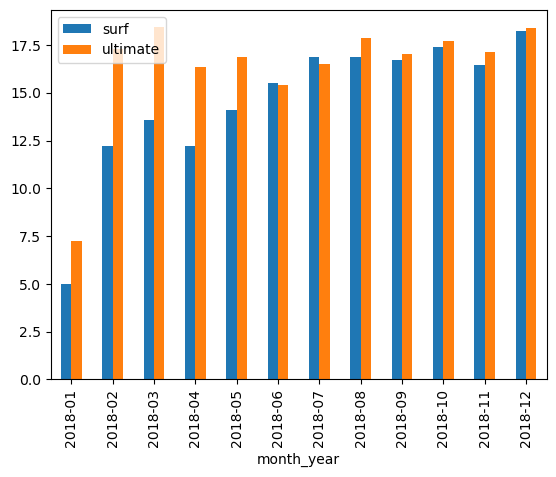

In [58]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan
df_monthly.groupby(['month_year', 'plan'])['gb_used'].mean().unstack().plot(kind="bar")
plt.legend(['surf', 'ultimate'])
plt.show()

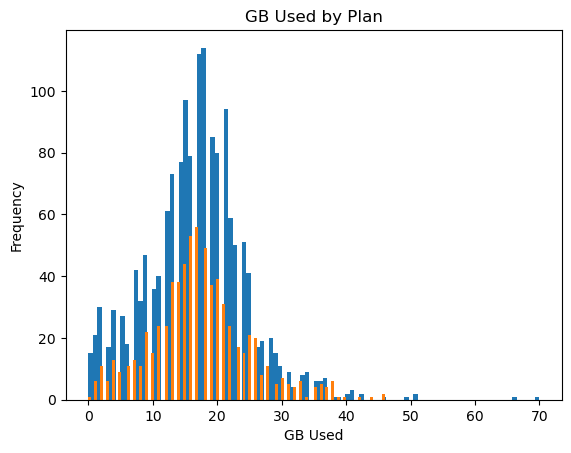

In [59]:
# Compara la cantidad de tráfico de Internet mensual consumido por usuarios por plan. Traza un histograma.
df_monthly[df_monthly['plan'] == "surf"]["gb_used"].plot(kind = 'hist', bins = 100)
df_monthly[df_monthly['plan'] == "ultimate"]["gb_used"].plot(kind = 'hist', bins = 100)

plt.xlabel('GB Used')
plt.ylabel('Frequency')
plt.title('GB Used by Plan')
plt.show()

[Elabora las conclusiones sobre cómo los usuarios tienden a consumir el tráfico de Internet. ¿Su comportamiento varía en función del plan?]

In [60]:
# Calcula la media y la varianza de la cantidad de tráfico de Internet.

df_monthly.groupby('plan')['gb_used'].describe()

,count,mean,std,min,25%,50%,75%,max
plan,,,,,,,,
surf,1573.0,16.670693,7.847522,0.0,12.0,17.0,21.0,70.0
ultimate,720.0,17.306944,7.670108,0.0,13.0,17.0,21.0,46.0


In [61]:
# varianza
print(np.var(df_monthly.query('plan == "ultimate"')['gb_used']))
print(np.var(df_monthly.query('plan == "surf"')['gb_used']))

58.748840663580125
61.544449424470265


In [62]:
# varianza mensual
df_monthly.groupby(['plan','month_year'])['gb_used'].var(ddof=0)

plan      month_year
surf      2018-01         9.000000
          2018-02        36.839506
          2018-03        61.202268
          2018-04        55.091600
          2018-05        57.427897
          2018-06        47.260070
          2018-07        60.968103
          2018-08        70.980072
          2018-09        48.986821
          2018-10        60.469618
          2018-11        54.414863
          2018-12        68.993196
ultimate  2018-01        11.187500
          2018-02        32.489796
          2018-03       127.076389
          2018-04        81.746032
          2018-05        52.325803
          2018-06        67.393391
          2018-07        63.165182
          2018-08        57.229518
          2018-09        46.709167
          2018-10        54.089712
          2018-11        53.962428
          2018-12        58.451384
Name: gb_used, dtype: float64

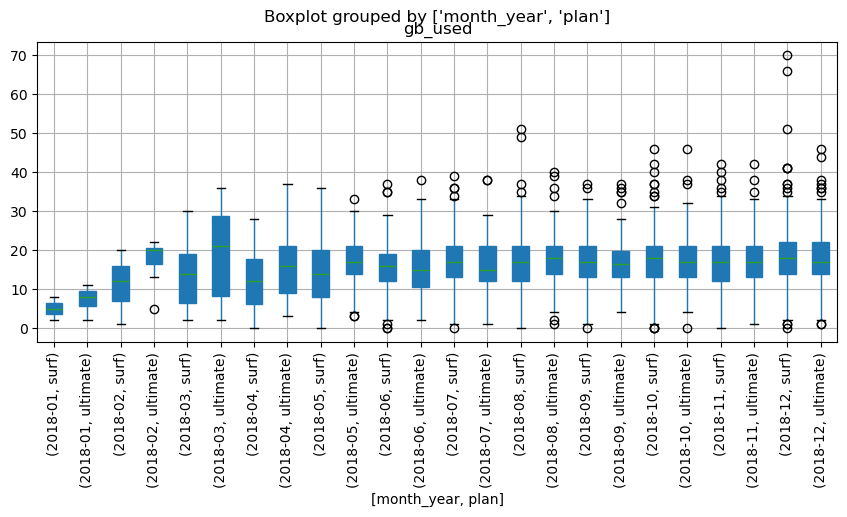

In [63]:
# diagrama de caja para visualizar la distribución de la cantidad de tráfico de Internet
# SOLUCIÓN 1
df_monthly.boxplot(column="gb_used", by=["month_year","plan"], figsize=(10,4), patch_artist=True)
plt.xticks(rotation=90)
plt.show()

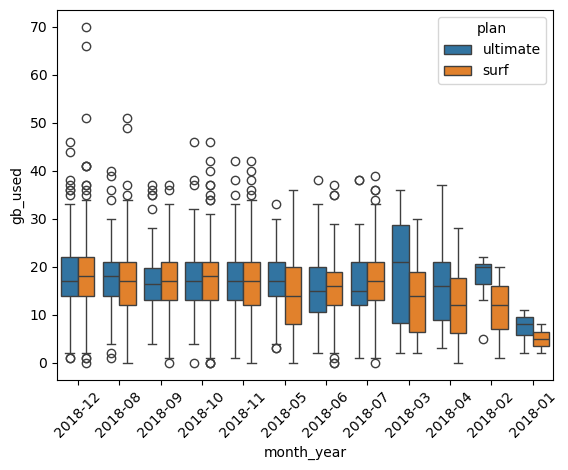

In [64]:
# Traza un diagrama de caja para visualizar la distribución de la cantidad de tráfico de Internet
# SOLUCIÓN 2: con seaborn (no visto en el curso)
sns.boxplot(data=df_monthly, x="month_year", y="gb_used", hue="plan")
plt.xticks(rotation=45)
plt.show()

## Ingreso

[Del mismo modo que has estudiado el comportamiento de los usuarios, describe estadísticamente los ingresos de los planes.]

Se analizan los ingresos generados por los usuarios de ambos planes con sus valores estadísticos asi como con sus gráficas.

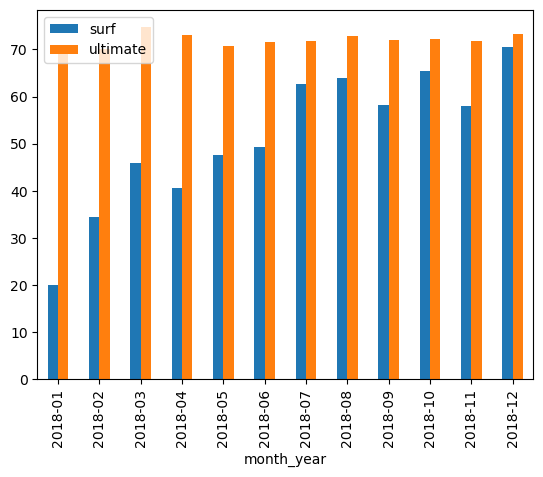

In [65]:
df_monthly.groupby(['month_year', 'plan'])['income'].mean().unstack().plot(kind="bar")
plt.legend(['surf', 'ultimate'])
plt.show()

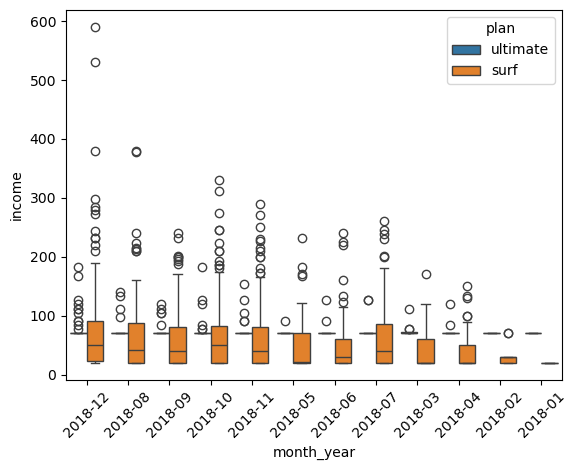

In [66]:
sns.boxplot(data=df_monthly, x="month_year", y="income", hue="plan")
plt.xticks(rotation=45)
plt.show()

[Elabora las conclusiones sobre cómo difiere el ingreso entre los planes.]

## Prueba las hipótesis estadísticas

[Prueba la hipótesis de que son diferentes los ingresos promedio procedentes de los usuarios de los planes de llamada Ultimate y Surf.]

### Hipótesis sobre igualdad de medias en los distintos planes
La primer hipótesis a probar es que el ingreso promedio mensual del plan surf es diferente al del ultimate.
- Hipótesis nula: el ingreso promedio mensual del plan surf es igual al del ultimate
- Hipótesis alterna: el ingreso promedio mensual del plan surf es diferente al del ultimate

Prueba estadística: Hipótesis sobre la igualdad de las medias de dos poblaciones

Valor alfa: 5%

In [67]:
#separar clientes por plan
df_monthly_s = df_monthly.query('plan == "surf"')
df_monthly_u = df_monthly.query('plan == "ultimate"')

In [69]:
# OPCIONAL: Prueba de igualdad de varianzas Levene (las especificaciones del proyecto no la piden))

alpha = 0.05 

var_test = st.levene(df_monthly_s['income'], df_monthly_u['income'])
print('p-value:', var_test.pvalue)

if var_test.pvalue < alpha:
    print("Se rechaza la hipótesis nula: las varianzas son diferentes")
else:
    print("No se rechaza la hipótesis nula: las varianzas pueden ser iguales")

p-value: 5.028876110654919e-83
Se rechaza la hipótesis nula: las varianzas son diferentes


In [70]:
# Prueba la hipótesis

#Prueba de hipótesis 1
h1 = st.ttest_ind(df_monthly_s['income'], df_monthly_u['income'], equal_var=False)
print('p-value: ', h1.pvalue)

if h1.pvalue < alpha:
    print("Se rechaza la hipótesis nula")
else:
    print("No se rechaza la hipótesis nula") 

p-value:  3.1703905481135738e-15
Se rechaza la hipótesis nula


[Prueba la hipótesis de que el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.]

### Hipótesis sobre igualdad de medias en distintas regiones
La segunda hipótesis a probar es que el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.
- Hipotesis nula: el ingreso promedio de los usuarios del área NY-NJ es igua al de los usuarios de otras regiones.
- Hipotesis alterna: el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones

Prueba estadística: Hipótesis sobre la igualdad de las medias de dos poblaciones

Valor alfa: 5%

In [71]:
# Prueba de hipótesis 2
h2 = st.ttest_ind(df_monthly.query('city == "New York-Newark-Jersey City, NY-NJ-PA MSA"')['income'], 
                  df_monthly.query('city != "New York-Newark-Jersey City, NY-NJ-PA MSA"')['income'])

print('p-value: ', h2.pvalue)

if h2.pvalue < alpha:
    print("Se rechaza la hipótesis nula")
else:
    print("No se rechaza la hipótesis nula") 


p-value:  0.043557431621342436
Se rechaza la hipótesis nula


## Conclusión general

[En esta sección final, enumera tus conclusiones importantes. Asegúrate de que estas abarquen todas las decisiones (suposiciones) importantes que adoptaste y que determinaron la forma elegida para procesar y analizar los datos.]